In [1]:
# Cell 1: Setup and Imports
%matplotlib inline
import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))  
sys.path.insert(0, PARENT_PROJECT_ROOT) 

from shap_rtl.plots import (
    waterfall, bar, beeswarm, summary_plot,
    heatmap, scatter, decision_plot, dependence_plot
)
from shap_rtl import RTLSHAPExplainer

# Output directory
OUTPUT_DIR = os.path.join(os.getcwd(), "Arabic_language_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"✅ Imports loaded successfully!")

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] RTL font initialized: NotoSansArabic-Regular.ttf
✅ Imports loaded successfully!


In [2]:
# Cell 2: Load Data and Train Model
DATA_FILE = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\rtl_multilingual_dataset.xlsx'

# Load dataset
df = pd.read_excel(DATA_FILE)
texts = df['cleaned_text'].astype(str).fillna('')

# Find label column
label_col = None
for col in ['multi_class', 'label', 'class', 'category', 'type', 'labels']:
    if col in df.columns:
        label_col = col
        break

if label_col is None:
    for col in df.columns:
        if df[col].dtype == 'object' and df[col].nunique() < 20:
            label_col = col
            break

labels_text = df[label_col]
print(f"📊 Using label column: {label_col}")

# Encode labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels_text)
class_names = label_encoder.classes_
print(f"📊 Classes: {class_names}")
print(f"📊 Samples: {len(texts)}")

# Train model - word n-grams for proper words
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    analyzer='word',
    max_features=500,
    min_df=2,
    max_df=0.9,
    token_pattern=r'(?u)\b\w+\b'
)

X = vectorizer.fit_transform(texts).toarray()

model = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced',
    solver='lbfgs'
).fit(X, labels)

print(f"✅ Model trained with {X.shape[1]} features")

📊 Using label column: multi_class
📊 Classes: ['General Violence' 'Neutral']
📊 Samples: 72
✅ Model trained with 149 features


In [3]:
# Cell 3: Arabic Tweet - NO FILTERING, JUST USE IT
arabic_tweet = "رياح خفيفة تحمل نسمات منعشة، يا لها من أجواء رائعة."
print(f"📝 Arabic Tweet: {arabic_tweet}")

# Vectorize and predict - NO FILTERING!
user_instance = vectorizer.transform([arabic_tweet]).toarray()[0]
present_idx = np.where(user_instance > 0)[0]
all_feature_names = list(vectorizer.get_feature_names_out())

user_pred = model.predict(user_instance.reshape(1, -1))[0]
user_prob = model.predict_proba(user_instance.reshape(1, -1))[0]
predicted_label = class_names[user_pred]

print(f"\n📊 Features present: {len(present_idx)}")
print(f"🔮 Prediction: {predicted_label}")
print(f"📊 Probability: {user_prob[user_pred]:.3f}")

📝 Arabic Tweet: رياح خفيفة تحمل نسمات منعشة، يا لها من أجواء رائعة.

📊 Features present: 2
🔮 Prediction: Neutral
📊 Probability: 0.645


In [4]:
# Cell 4: Compute SHAP Values - NO FILTERING!
masker = shap.maskers.Independent(data=X, max_samples=100)
explainer_shap = shap.LinearExplainer(model, masker=masker)

# Get SHAP values
user_shap_vals = explainer_shap(user_instance.reshape(1, -1))

if isinstance(user_shap_vals, list):
    user_shap_values_class = user_shap_vals[user_pred][0]
    base_value = explainer_shap.expected_value[user_pred]
else:
    user_shap_values_class = user_shap_vals[0]
    base_value = explainer_shap.expected_value

# Get all features present (NO FILTERING!)
present_idx = np.where(user_instance > 0)[0]
feature_names = [all_feature_names[i] for i in present_idx]
user_shap_values = user_shap_values_class[present_idx]
user_data = user_instance[present_idx]

# Create SHAP Explanation - ALL features, RTL handled by shap_rtl!
shap_exp_user = shap.Explanation(
    values=user_shap_values,
    base_values=base_value,
    data=user_data,
    feature_names=feature_names
)

print(f"✅ SHAP shape: {shap_exp_user.values.shape}")

✅ SHAP shape: (2,)


In [5]:
# Cell 5: Save Plots Helper
def save_plot(filename, dpi=300, bbox_inches='tight'):
    filepath = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(filepath, dpi=dpi, bbox_inches=bbox_inches)
    plt.close()
    print(f"  ✅ Saved: {filename}")


WATERFALL PLOT - ARABIC


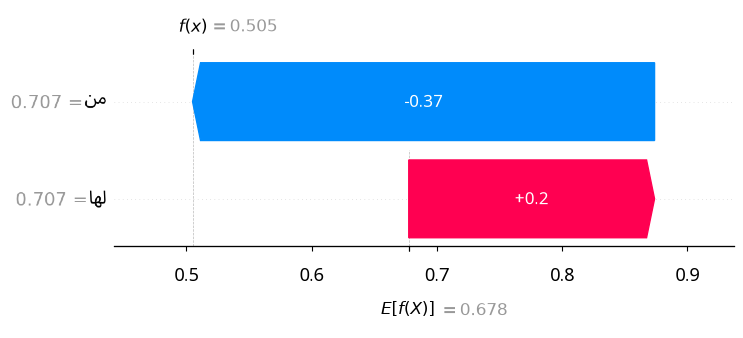

  ✅ Saved: waterfall_arabic.png


In [6]:
# Cell 6: Waterfall Plot
print("\n" + "="*80)
print("WATERFALL PLOT - ARABIC")
print("="*80)

if len(shap_exp_user.values) > 1:
    plt.figure(figsize=(12, 8))
    waterfall(
        shap_values=shap_exp_user,
        max_display=min(10, len(shap_exp_user.values)),
        show=True
    )
    plt.show()
    save_plot("waterfall_arabic.png")
else:
    print("⚠️ Not enough features")


BAR PLOT - ARABIC


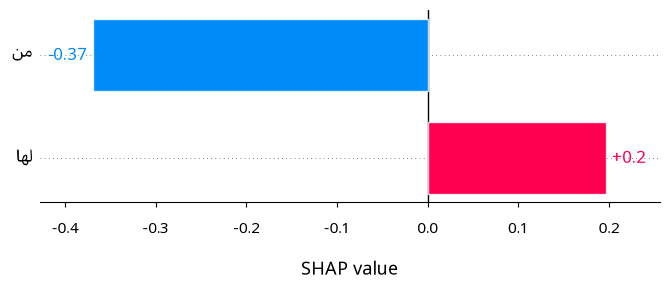

  ✅ Saved: bar_arabic.png


In [7]:
# Cell 7: Bar Plot
print("\n" + "="*80)
print("BAR PLOT - ARABIC")
print("="*80)

if len(shap_exp_user.values) > 1:
    plt.figure(figsize=(12, 8))
    bar(
        shap_values=shap_exp_user,
        max_display=min(10, len(shap_exp_user.values)),
        show=True
    )
    plt.show()
    save_plot("bar_arabic.png")
else:
    print("⚠️ Not enough features")

In [8]:
# Cell 8: Combined Explanation for Multi-Sample Plots
n_samples = min(50, len(df))
random_indices = np.random.choice(len(df), n_samples, replace=False)
X_subset = X[random_indices]
shap_values = explainer_shap.shap_values(X_subset)

if isinstance(shap_values, list):
    shap_values_class = shap_values[user_pred]
    base_values = explainer_shap.expected_value[user_pred]
else:
    shap_values_class = shap_values
    base_values = explainer_shap.expected_value

shap_exp_combined = shap.Explanation(
    values=shap_values_class,
    base_values=base_values,
    data=X_subset,
    feature_names=all_feature_names
)

print(f"✅ Combined SHAP shape: {shap_exp_combined.values.shape}")

✅ Combined SHAP shape: (50, 149)



BEESWARM PLOT - ARABIC


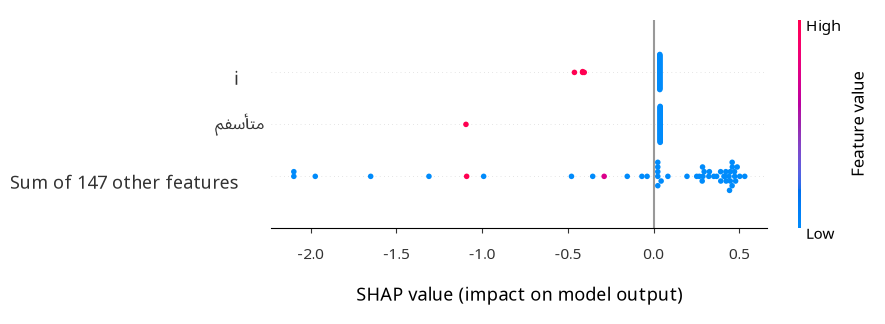

  ✅ Saved: beeswarm_arabic.png


In [11]:
# Cell 9: Beeswarm Plot
print("\n" + "="*80)
print("BEESWARM PLOT - ARABIC")
print("="*80)

plt.figure(figsize=(14, 10))
beeswarm(
    shap_values=shap_exp_combined,
    max_display=3,
    show=True
)
plt.show()
save_plot("beeswarm_arabic.png")


HEATMAP - ARABIC


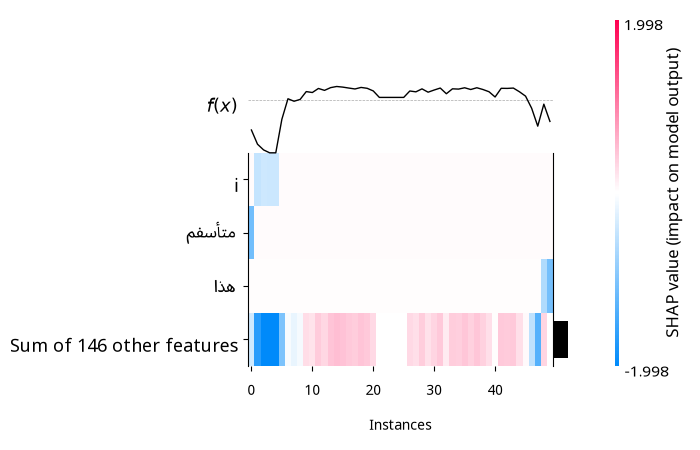

  ✅ Saved: heatmap_arabic.png


In [15]:
# Cell 11: Heatmap
print("\n" + "="*80)
print("HEATMAP - ARABIC")
print("="*80)

plt.figure(figsize=(14, 10))
heatmap(
    shap_values=shap_exp_combined,
    max_display=4,
    show=True,
    instance_order=None
)
plt.show()
save_plot("heatmap_arabic.png")


SCATTER PLOT - ARABIC


<Figure size 1200x800 with 0 Axes>

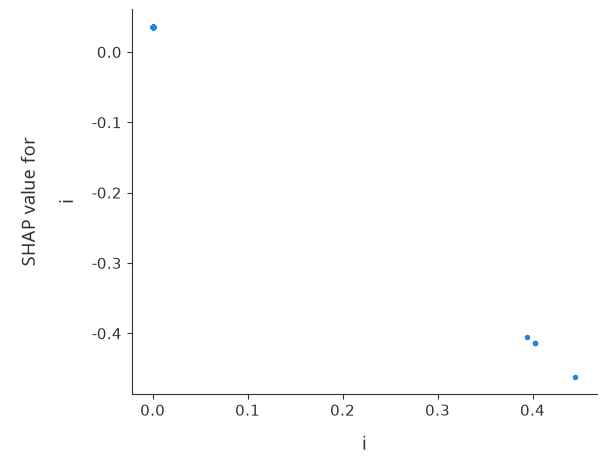

  ✅ Saved: scatter_arabic.png


In [16]:
# Cell 12: Scatter Plot
print("\n" + "="*80)
print("SCATTER PLOT - ARABIC")
print("="*80)

plt.figure(figsize=(12, 8))
scatter(
    shap_values=shap_exp_combined,
    max_display=10,
    show=True
)
plt.show()
save_plot("scatter_arabic.png")


DECISION PLOT - ARABIC


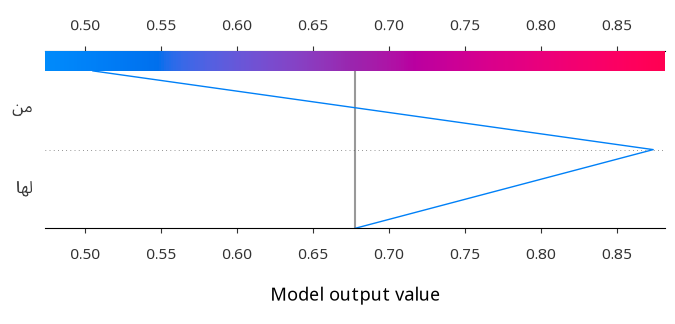

  ✅ Saved: decision_arabic.png


In [17]:
# Cell 13: Decision Plot
print("\n" + "="*80)
print("DECISION PLOT - ARABIC")
print("="*80)

if len(shap_exp_user.values) > 1:
    plt.figure(figsize=(12, 8))
    decision_plot(
        base_value=shap_exp_user.base_values,
        shap_values=shap_exp_user.values.reshape(1, -1),
        feature_names=feature_names,
        show=True
    )
    plt.show()
    save_plot("decision_arabic.png")
else:
    print("⚠️ Not enough features")